In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot
import matplotlib.patheffects as path_effects

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

First let's define a plotting function for all the cases that we will study:

In [34]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label
    
def make_oscillogram_plot(nu_i, nu_f, costhz_arr, log10_Enu_arr, prob_arr, cbar_label_pre='',
                          save_plot=False, path=None, filename=None, format=None):

    heights, widths = [1.0], [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[9,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    # Select the probability to plot
    prob_sel_arr = prob_arr[:,:,nu_i,nu_f]
    # print(prob_sel_arr)

    # Plot
    cs = ax.contourf(costhz_arr, log10_Enu_arr, prob_sel_arr, levels=120, cmap=mpl.cm.plasma) #120
    cbar = fig.colorbar(cs)
    cbar.ax.tick_params(labelsize=25) 
    cbar.set_label(label=cbar_label_pre + prob_label(nu_i, nu_f), fontsize=25)

    # Annotations
    text = fig.text(0.12, 0.95, prob_label(nu_i, nu_f),  ha='center', va='center', size=25, color='k', rotation=0.,
                   transform=ax.transAxes)
    text.set_path_effects([path_effects.Stroke(linewidth=12, foreground='white'), path_effects.Normal()])

    # Formatting
    ax.set_xlim([costhz_min, costhz_max])
    ax.set_ylim([log10_Enu_min, log10_Enu_max])
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.02))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))
    ax.set_xlabel(r'Zenith angle, $\cos(\theta_z)$')
    ax.set_ylabel(r'Neutrino energy, $\log_{10}(E_\nu/{\rm GeV})$')

    if save_plot:
        plt.savefig(path+filename+'.'+format, bbox_inches='tight', dpi=200)

Define the coherent forward potential inside the Earth according to the PREM matter density model

In [30]:
# r is the radius from the center of the Earth [km]
def VCC_func_prem(r):
    return matter.VCC_func(r, lambda rr : matter.num_density_e_func(rr, earth.density_matter_func_prem, electron_fraction=0.5)) # [eV]

Define the ranges of zenith angle (and, therefore, baseline) and neutrino energies

In [41]:
# Cosines of zenith angles
costhz_min, costhz_max, costhz_npts = -1.0, 0.0, 200
costhz_arr = np.linspace(costhz_min, costhz_max, costhz_npts) 

# Baselines, L [km]
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] 

# Neutrino energies [GeV]
log10_Enu_min, log10_Enu_max, Enu_npts = 0.0, 2.0, 200
Enu_arr = np.logspace(log10_Enu_min, log10_Enu_max, Enu_npts)
log10_Enu_arr = np.log10(Enu_arr)

Generate and plot the $2\nu$ oscillograms.  First, we define the Hamiltonians:

In [43]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
sth = gd.S12_NO_BF_NUFIT_6_0 # [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_2nu_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(sth, Dm2) # [eV^2]

# Matter Hamiltonian
def H_2nu_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    # print(costhz, l/gd.CONV_KM_TO_INV_EV, r)
    return (1/energy)*H_vac_2nu_energy_indep - hamiltonians2nu.hamiltonian_2nu_matter(VCC_func_prem(r)) # [eV]

Next, generate the probabilities for all combinations of costhz, where `prob_2nu[i][j]` contains a $2 \times 2$ matrix `[[Pee, Pem], [Pme, Pmm]]` evaluated at `Enu_arr[i]` and `costhz_arr[j]`:

In [38]:
prob_2nu = np.array([[oscprob.osc_prob(lambda l: H_2nu_func_prem(costhz_arr[j], l, Enu_arr[i]*gd.UNIT_GEV),
                                       0, l_max_arr[j]*gd.CONV_KM_TO_INV_EV, 
                                       n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10) #100, 20,3, 10
                  for j in range(costhz_npts)] for i in range(Enu_npts)])

In [42]:
# print(prob_2nu.shape)
# prob_2nu[0]
# prob_2nu[:, :, 0, 0]

Now plot the oscillogram:

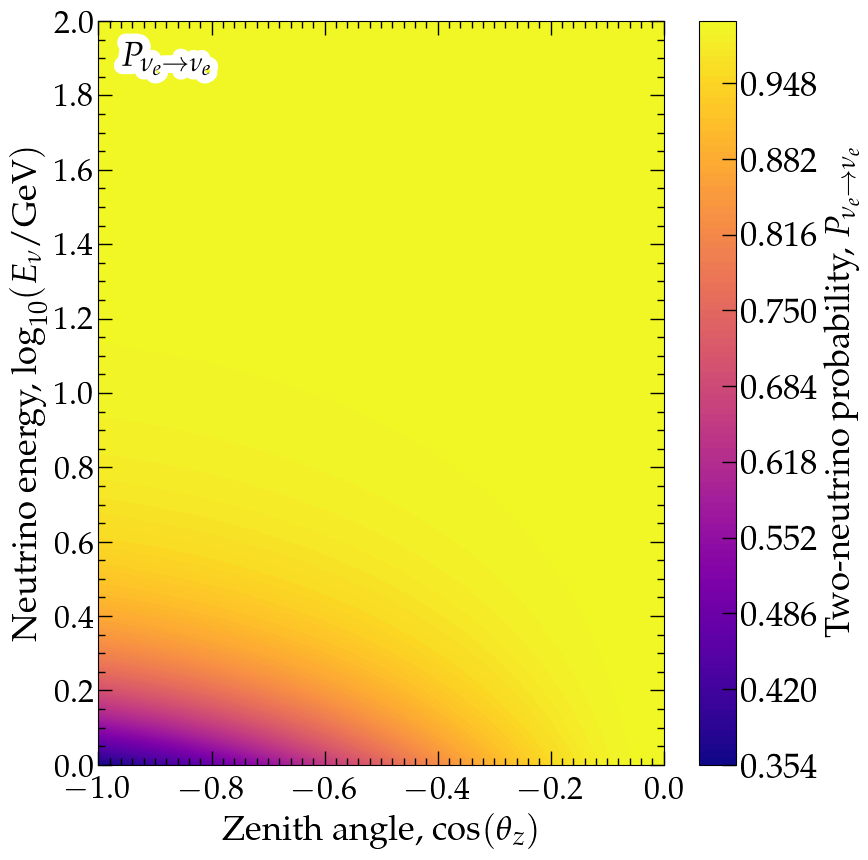

In [40]:
make_oscillogram_plot(gd.NUE, gd.NUE, costhz_arr, log10_Enu_arr, prob_2nu, 
                      cbar_label_pre=r'Two-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)

Now let's do the same for $3\nu$ oscillations.  First, define the Hamiltonians:

In [44]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Vacuum Hamiltonian without the (1/E) prefactor
H_vac_3nu_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31) # [eV^2]

# Matter Hamiltonian
def H_3nu_func_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) 
    # print(costhz, l/gd.CONV_KM_TO_INV_EV, r)
    return (1/energy)*H_vac_3nu_energy_indep - hamiltonians3nu.hamiltonian_3nu_matter(VCC_func_prem(r)) # [eV]

Next, generate the probabilities for all combinations of costhz, where `prob_3nu[i][j]` contains a $3 \times 3$ matrix `[[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]` evaluated at `Enu_arr[i]` and `costhz_arr[j]`:

In [45]:
prob_3nu = np.array([[oscprob.osc_prob(lambda l: H_3nu_func_prem(costhz_arr[j], l, Enu_arr[i]*gd.UNIT_GEV),
                                       0, l_max_arr[j]*gd.CONV_KM_TO_INV_EV, 
                                       n_slabs=10, n_tpts_per_slab=3, magnus_exp_order=1, n_jobs=1) #100, 20,3, 10
                  for j in range(costhz_npts)] for i in range(Enu_npts)])

Now plot the oscillograms:

TypeError: Length of x (2) must match number of columns in z (3)

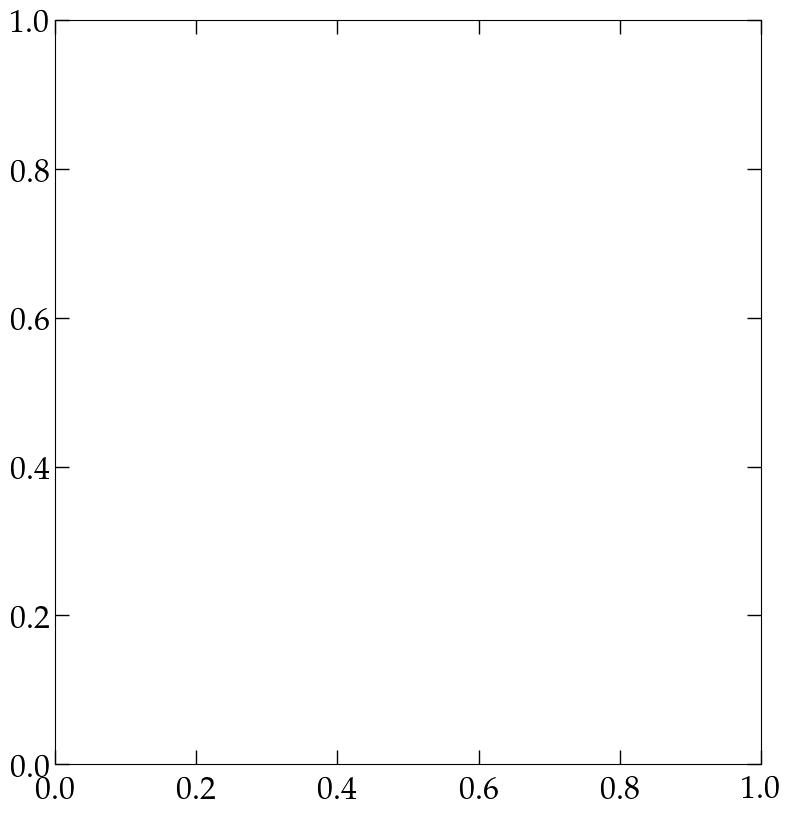

In [46]:
make_oscillogram_plot(gd.NUE, gd.NUE, costhz_arr, log10_Enu_arr, prob_3nu, 
                      cbar_label_pre=r'Three-neutrino probability, ', save_plot=False, path=None, filename=None, format=None)